In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)


In [2]:
core_df = pd.read_csv(r"D:\spotify\data\processed\cleaned\core_cleaned.csv")
audio_df = pd.read_csv(r"D:\spotify\data\processed\cleaned\audio_features_cleaned.csv")
genre_df = pd.read_csv(r"D:\spotify\data\processed\cleaned\genres_cleaned.csv")
charts_df = pd.read_csv(r"D:\spotify\data\processed\cleaned\top_charts_cleaned.csv")


In [4]:
print("CORE COLUMNS:\n", core_df.columns)
print("\nAUDIO COLUMNS:\n", audio_df.columns)
print("\nGENRE COLUMNS:\n", genre_df.columns)
print("\nCHARTS COLUMNS:\n", charts_df.columns)


CORE COLUMNS:
 Index(['track_id', 'track_name', 'track_number', 'track_popularity',
       'explicit', 'artist_name', 'artist_popularity', 'artist_followers',
       'artist_genres', 'album_id', 'album_name', 'album_release_date',
       'album_total_tracks', 'album_type', 'track_duration_min', 'merge_key'],
      dtype='object')

AUDIO COLUMNS:
 Index(['artist_name', 'track_id', 'track_name', 'acousticness', 'danceability',
       'duration_ms', 'energy', 'instrumentalness', 'key', 'liveness',
       'loudness', 'mode', 'speechiness', 'tempo', 'time_signature', 'valence',
       'popularity', 'merge_key'],
      dtype='object')

GENRE COLUMNS:
 Index(['track_id', 'artists', 'album_name', 'track_name', 'popularity',
       'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness',
       'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness',
       'valence', 'tempo', 'time_signature', 'track_genre'],
      dtype='object')

CHARTS COLUMNS:
 Index(['id', 'ar

In [5]:
def create_merge_key_flexible(df):
    # Possible column name variants
    track_cols = ["track_name", "track", "song_name", "name"]
    artist_cols = ["artist_name", "artist", "artists", "artist_names"]

    track_col = next((c for c in track_cols if c in df.columns), None)
    artist_col = next((c for c in artist_cols if c in df.columns), None)

    if track_col is None or artist_col is None:
        raise ValueError(
            f"Required columns not found. Found columns: {df.columns}"
        )

    return (
        df[track_col].astype(str).str.lower().str.strip() + "_" +
        df[artist_col].astype(str).str.lower().str.strip()
    )


In [7]:
def create_merge_key(df):
    return (
        df["track_name"].str.lower().str.strip() + "_" +
        df["artist_name"].str.lower().str.strip()
    )

core_df["merge_key"] = create_merge_key_flexible(core_df)
audio_df["merge_key"] = create_merge_key_flexible(audio_df)
genre_df["merge_key"] = create_merge_key_flexible(genre_df)
charts_df["merge_key"] = create_merge_key_flexible(charts_df)


In [9]:
merged_genre_df = (
    core_df
    .merge(audio_df, on="merge_key", how="inner")
    .merge(genre_df[["merge_key", "track_genre"]], on="merge_key", how="left")
    .drop_duplicates()
)


In [11]:
merged_genre_df["track_genre"].value_counts().head(10)


track_genre
dance          50
rock           41
electro        35
pop            28
alt-rock       24
alternative    22
house          20
indie-pop      18
k-pop          18
indie          15
Name: count, dtype: int64

In [ ]:
top_genres = (
    merged_genre_df["track_genre"]
    .value_counts()
    .head(10)
    .index
)

genre_filtered_df = merged_genre_df[
    merged_genre_df["track_genre"].isin(top_genres)
]


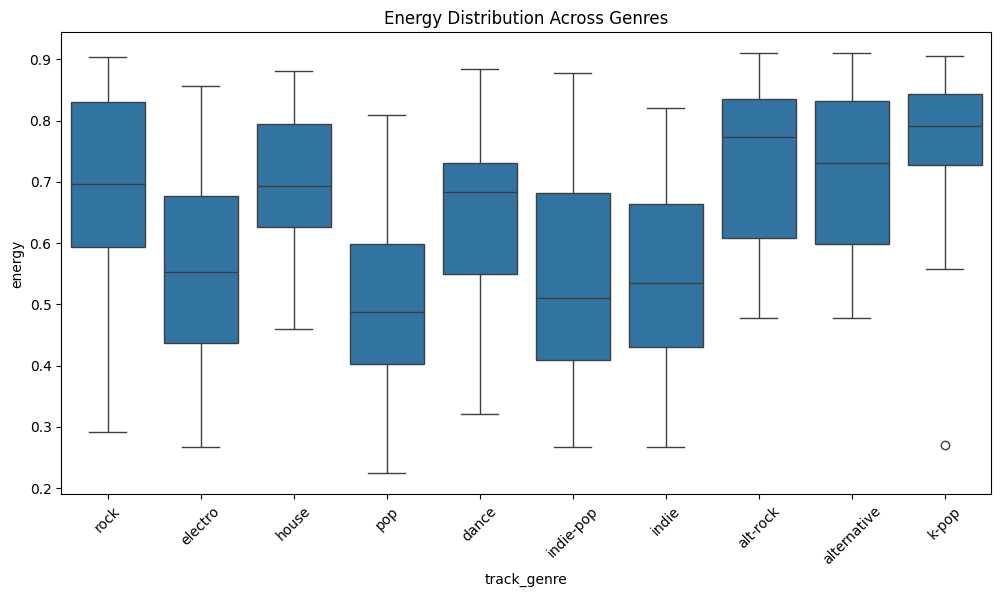

In [14]:
plt.figure(figsize=(12,6))
sns.boxplot(
    data=genre_filtered_df,
    x="track_genre",
    y="energy"
)
plt.xticks(rotation=45)
plt.title("Energy Distribution Across Genres")
plt.show()


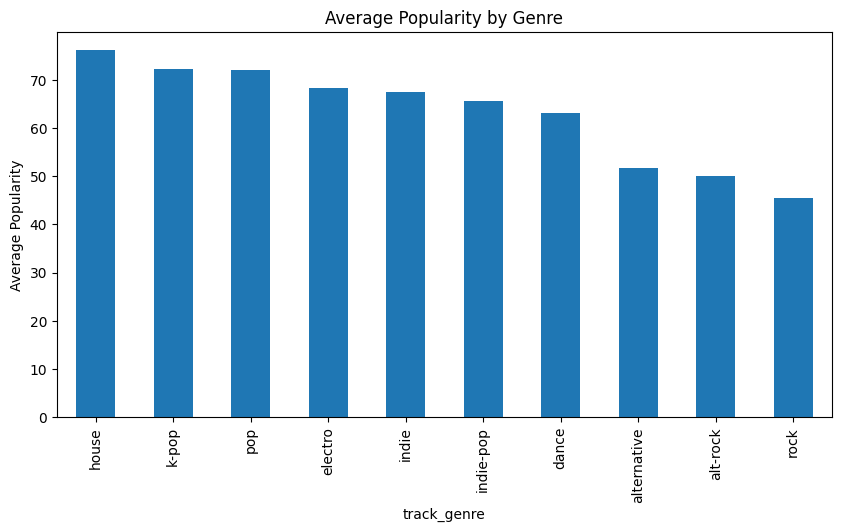

In [15]:
genre_popularity = (
    genre_filtered_df
    .groupby("track_genre")["popularity"]
    .mean()
    .sort_values(ascending=False)
)

genre_popularity.plot(
    kind="bar",
    figsize=(10,5),
    title="Average Popularity by Genre"
)
plt.ylabel("Average Popularity")
plt.show()


In [16]:
merged_genre_df["is_chart_song"] = (
    merged_genre_df["merge_key"]
    .isin(charts_df["merge_key"])
)


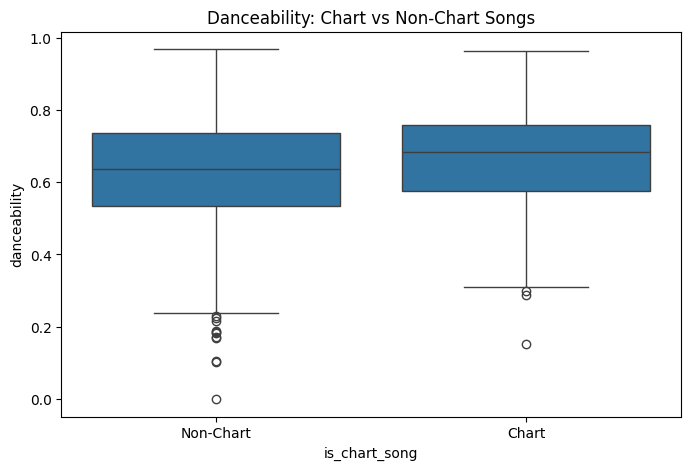

In [17]:
plt.figure(figsize=(8,5))
sns.boxplot(
    data=merged_genre_df,
    x="is_chart_song",
    y="danceability"
)
plt.xticks([0,1], ["Non-Chart", "Chart"])
plt.title("Danceability: Chart vs Non-Chart Songs")
plt.show()


In [18]:
genre_filtered_df.to_csv(
    r"D:\spotify\data\processed\analytics_ready\genre_audio_analysis.csv",
    index=False
)

merged_genre_df.to_csv(
    r"D:\spotify\data\processed\analytics_ready\chart_vs_nonchart.csv",
    index=False
)
